# 🚀 Emotion Regulation Analysis — Colab Training (v4)

**Strategy:**
- 📦 IEMOCAP Session1 only → Colab local `/content/` (only session with video)
- 💾 Checkpoints only → Google Drive (~100 MB)
- 🔬 MOSEI 500 samples → pre-extracted features via CMU-MultimodalSDK

**Dataset split:**
| Split | Data | Purpose |
|-------|------|---------|
| Train (80%) | IEMOCAP Session1 | Train both models |
| Val (20%) | IEMOCAP Session1 | Held-out validation |
| Eval | CMU-MOSEI 500 clips | Cross-dataset test (frozen model) |

**Run all cells top to bottom. Runtime: ~2–4 hours.**

## ⚙️ STEP 0: Set Runtime to GPU

Runtime → Change runtime type → T4 GPU → Save

## 📦 STEP 1: Install Dependencies

In [1]:
!pip install -q kaggle
!pip install -q mediapipe==0.10.14 librosa soundfile transformers tqdm tensorboard opencv-python scikit-learn
!pip install -q git+https://github.com/CMU-MultiComp-Lab/CMU-MultimodalSDK.git
print('✓ All packages installed')
print('⚠️  RESTART RUNTIME NOW: Runtime → Restart runtime → then continue from STEP 2')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 23.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.7 MB/s eta 0:00:00
✓ All packages installed
⚠️  RESTART RUNTIME NOW: Runtime → Restart runtime → then continue from STEP 2


## 🔄 STEP 1.5: Restart Runtime

In [ ]:
import os
os.kill(os.getpid(), 9)

## ✅ STEP 2: Verify GPU

In [1]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU — Runtime → Change runtime type → T4 GPU')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


## 💾 STEP 3: Mount Google Drive (checkpoints only)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Google Drive — checkpoints and results ONLY
DRIVE_BASE     = Path('/content/drive/MyDrive/emotion_regulation')
CHECKPOINT_DIR = DRIVE_BASE / 'checkpoints'
RESULTS_DIR    = DRIVE_BASE / 'results'
LOGS_DIR       = DRIVE_BASE / 'logs'
for d in [CHECKPOINT_DIR, RESULTS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Colab local — data, code, processed features
LOCAL_BASE    = Path('/content/emotion_regulation')
IEMOCAP_DIR   = LOCAL_BASE / 'IEMOCAP'
MOSEI_DIR     = LOCAL_BASE / 'MOSEI'
PROCESSED_DIR = LOCAL_BASE / 'processed'

for d in [IEMOCAP_DIR, MOSEI_DIR, PROCESSED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

!mkdir -p /content/emotion_regulation/code/{encoders,models,utils}
!touch /content/emotion_regulation/code/__init__.py
!touch /content/emotion_regulation/code/encoders/__init__.py
!touch /content/emotion_regulation/code/models/__init__.py
!touch /content/emotion_regulation/code/utils/__init__.py

print('✓ Drive mounted  →  checkpoints saved there')
print('✓ Local dirs ready  →  data lives here')

Mounted at /content/drive
✓ Drive mounted  →  checkpoints saved there
✓ Local dirs ready  →  data lives here


## 📥 STEP 4: Download IEMOCAP — Session1 Only

Uses `kaggle` CLI to download only Session1 (the only session with video files).  
Sessions 2–5 are **never extracted**, so they waste zero space.

In [4]:
# ── Kaggle credentials ──────────────────────────────────────────────────────
# Option A: paste credentials directly
import os
os.environ['KAGGLE_USERNAME'] = 'Kanishk_Pandey1906'  # ⬅️ CHANGE THIS
os.environ['KAGGLE_KEY']      = 'KGAT_5271883df182ac803a8c92cfbad62699'   # ⬅️ CHANGE THIS

# Option B: upload kaggle.json instead (uncomment below)
# from google.colab import files
# files.upload()   # upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# ── Download only Session1 ──────────────────────────────────────────────────
from pathlib import Path

IEMOCAP_DIR = Path('/content/emotion_regulation/IEMOCAP')

if (IEMOCAP_DIR / 'Session1').exists():
    print('✓ Session1 already downloaded')
    !ls {IEMOCAP_DIR}/Session1
else:
    print('Downloading IEMOCAP zip...')
    print('⏱️  ~10–20 minutes')

    # Download zip to /content (not Google Drive)
    !kaggle datasets download -d jamaliasultanajisha/iemocap-full -p /content

    # Extract Session1 only — this is the only session that has .avi video files
    print('\nExtracting Session1 only...')
    !unzip -q /content/iemocap-full.zip "IEMOCAP_full_release/Session1/*" -d /content/iemocap_tmp

    # Move to working directory
    import shutil
    src = Path('/content/iemocap_tmp/IEMOCAP_full_release/Session1')
    dst = IEMOCAP_DIR / 'Session1'
    if src.exists():
        shutil.copytree(str(src), str(dst), dirs_exist_ok=True)
        print('✓ Session1 copied to working directory')
    else:
        # Fallback: zip may use different root
        print('Checking zip structure...')
        !unzip -l /content/iemocap-full.zip | head -30

    # Delete the zip and tmp folder to free space
    !rm -f /content/iemocap-full.zip
    !rm -rf /content/iemocap_tmp
    print('✓ Zip deleted — space freed')

print('\nSession1 structure:')
!ls {IEMOCAP_DIR}/Session1

print('\nDisk usage:')
!df -h /content | tail -1

⏱️  ~10–20 minutes
Dataset URL: https://www.kaggle.com/datasets/jamaliasultanajisha/iemocap-full
License(s): unknown
^C

Extracting Session1 only...
unzip:  cannot find or open /content/iemocap-full.zip, /content/iemocap-full.zip.zip or /content/iemocap-full.zip.ZIP.
Checking zip structure...
unzip:  cannot find or open /content/iemocap-full.zip, /content/iemocap-full.zip.zip or /content/iemocap-full.zip.ZIP.
✓ Zip deleted — space freed

Session1 structure:
ls: cannot access '/content/emotion_regulation/IEMOCAP/Session1': No such file or directory

Disk usage:
overlay         113G   44G   70G  39% /


In [5]:
# Install kagglehub
!pip install -q kagglehub

import kagglehub
from pathlib import Path
import shutil

print("Downloading IEMOCAP via kagglehub (cached download)...")

# Download dataset (stored in cache)
dataset_path = kagglehub.dataset_download("jamaliasultanajisha/iemocap-full")

print("Dataset downloaded to:")
print(dataset_path)

# Paths
src = Path(dataset_path) / "IEMOCAP_full_release" / "Session1"
dst = Path("/content/emotion_regulation/IEMOCAP/Session1")

# Copy Session1 only
dst.mkdir(parents=True, exist_ok=True)

print("\nCopying Session1 only...")
shutil.copytree(src, dst, dirs_exist_ok=True)

print("✓ Session1 copied successfully")

# Show structure
print("\nSession1 structure:")
!ls /content/emotion_regulation/IEMOCAP/Session1/dialog

# Check disk
print("\nDisk usage:")
!df -h /content | tail -1

100%|██████████| 11.6G/11.6G [09:32<00:00, 21.7MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/jamaliasultanajisha/iemocap-full/versions/1

Copying Session1 only...
✓ Session1 copied successfully

Session1 structure:
avi	       lab	   MOCAP_head	  transcriptions
EmoEvaluation  MOCAP_hand  MOCAP_rotated  wav

Disk usage:
overlay         113G   72G   42G  64% /


## ⚙️ STEP 5: Write Config

In [6]:
%%writefile /content/emotion_regulation/code/utils/config.py
import torch
from pathlib import Path

# Colab local paths
LOCAL_BASE    = Path('/content/emotion_regulation')
IEMOCAP_DIR   = LOCAL_BASE / 'IEMOCAP'
MOSEI_DIR     = LOCAL_BASE / 'MOSEI'
PROCESSED_DIR = LOCAL_BASE / 'processed'

# Google Drive paths (checkpoints + results only)
DRIVE_BASE     = Path('/content/drive/MyDrive/emotion_regulation')
CHECKPOINT_DIR = DRIVE_BASE / 'checkpoints'
RESULTS_DIR    = DRIVE_BASE / 'results'
LOGS_DIR       = DRIVE_BASE / 'logs'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Only Session1 is used — 80/20 split
TRAIN_SESSION      = 'Session1'
MOSEI_EVAL_SAMPLES = 500

# Feature dimensions (verified from actual extraction)
FACE_DIM  = 944
AUDIO_DIM = 44   # actual extracted dim = 44 (not 42)
TEXT_DIM  = 796
INPUT_DIM = FACE_DIM + AUDIO_DIM + TEXT_DIM  # = 1784

INCONGRUENCE_CONFIG = {
    'input_dim':   INPUT_DIM,
    'hidden_dims': [512, 256, 128],
    'output_dim':  64,
    'dropout':     0.3
}
TEMPORAL_CONFIG    = {'input_dim': 64, 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.3}
INCONGRUENCE_TRAIN = {'batch_size': 32, 'learning_rate': 1e-3, 'epochs': 15, 'weight_decay': 1e-5}
TEMPORAL_TRAIN     = {'batch_size': 32, 'learning_rate': 1e-3, 'epochs': 20, 'weight_decay': 1e-5, 'sequence_length': 20}
AUDIO_CONFIG       = {'sample_rate': 16000, 'n_mfcc': 13, 'n_fft': 2048, 'hop_length': 512}
TEXT_CONFIG        = {'model_name': 'SamLowe/roberta-base-go_emotions', 'max_length': 128}
RANDOM_SEED        = 42

print(f'Config loaded. Device: {DEVICE}  |  Input dim: {INPUT_DIM}')

Writing /content/emotion_regulation/code/utils/config.py


## 🎨 STEP 6: Write Encoders

In [7]:
%%writefile /content/emotion_regulation/code/encoders/face_encoder.py
import cv2
import mediapipe as mp
import numpy as np
from typing import Optional

FACE_DIM = 944  # 468 landmarks × 2 (x,y) + 8 expressiveness features

class FaceEncoder:
    def __init__(self):
        mp_fm = mp.solutions.face_mesh
        self.face_mesh = mp_fm.FaceMesh(
            static_image_mode=False, max_num_faces=1,
            min_detection_confidence=0.5, min_tracking_confidence=0.5
        )

    def extract_from_video(self, video_path: str, skip_frames: int = 5) -> Optional[np.ndarray]:
        cap = cv2.VideoCapture(video_path)
        seq, idx = [], 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            if idx % skip_frames == 0:
                feat = self.extract_from_frame(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                if feat is not None:
                    seq.append(feat)
            idx += 1
        cap.release()
        return np.array(seq) if seq else None

    def extract_from_frame(self, frame: np.ndarray) -> Optional[np.ndarray]:
        res = self.face_mesh.process(frame)
        if not res.multi_face_landmarks: return None
        fl = res.multi_face_landmarks[0]
        lm = [v for l in fl.landmark for v in [l.x, l.y]]
        return np.concatenate([lm, self._expressiveness(fl)])

    def _expressiveness(self, fl) -> np.ndarray:
        lms = [(l.x, l.y, l.z) for l in fl.landmark]
        f = []
        f += [np.linalg.norm(np.array(lms[33]) - np.array(lms[160])),
              np.linalg.norm(np.array(lms[362]) - np.array(lms[385]))]
        f += [np.linalg.norm(np.array(lms[13]) - np.array(lms[14])),
              np.linalg.norm(np.array(lms[61]) - np.array(lms[291]))]
        f += [lms[70][2], lms[300][2],
              abs(lms[234][2] - lms[454][2]),
              np.linalg.norm(np.array(lms[152]) - np.array(lms[10]))]
        return np.array(f)

    def zero_features(self, n_frames: int = 10) -> np.ndarray:
        """Fallback: return zero feature array when face detection fails."""
        return np.zeros((n_frames, FACE_DIM))

    def close(self): self.face_mesh.close()

Writing /content/emotion_regulation/code/encoders/face_encoder.py


In [8]:
%%writefile /content/emotion_regulation/code/encoders/audio_encoder.py
import librosa
import numpy as np
from typing import Optional
import warnings; warnings.filterwarnings('ignore')

class AudioEncoder:
    def __init__(self, sample_rate=16000, n_mfcc=13, n_fft=2048, hop_length=512):
        self.sr     = sample_rate
        self.n_mfcc = n_mfcc
        self.n_fft  = n_fft
        self.hop    = hop_length

    def extract_from_file(self, path: str) -> Optional[np.ndarray]:
        try:
            y, sr = librosa.load(path, sr=self.sr)
            return self.extract_from_signal(y, sr) if len(y) > 0 else None
        except:
            return None

    def extract_from_signal(self, y, sr=None) -> np.ndarray:
        sr   = sr or self.sr
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=self.n_mfcc, n_fft=self.n_fft, hop_length=self.hop)
        d1   = librosa.feature.delta(mfcc)
        d2   = librosa.feature.delta(mfcc, order=2)
        f0, _, _ = librosa.pyin(y, fmin=65, fmax=2093, sr=sr, hop_length=self.hop)
        f0   = np.nan_to_num(f0, nan=0.0)
        rms  = librosa.feature.rms(y=y, hop_length=self.hop)[0]
        zcr  = librosa.feature.zero_crossing_rate(y, hop_length=self.hop)[0]
        cent = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=self.hop)[0]
        roll = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=self.hop)[0]
        bw   = librosa.feature.spectral_bandwidth(y=y, sr=sr, hop_length=self.hop)[0]
        flat = librosa.feature.spectral_flatness(y=y, hop_length=self.hop)[0]
        # 13+13+13+1+1+1+1+1+1+1 = 46 features — trimmed to actual
        return np.vstack([
            mfcc, d1, d2,
            f0.reshape(1,-1), rms.reshape(1,-1), zcr.reshape(1,-1),
            cent.reshape(1,-1), roll.reshape(1,-1), bw.reshape(1,-1), flat.reshape(1,-1)
        ]).T

Writing /content/emotion_regulation/code/encoders/audio_encoder.py


In [9]:
%%writefile /content/emotion_regulation/code/encoders/text_encoder.py
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import warnings; warnings.filterwarnings('ignore')

class TextEncoder:
    def __init__(self, model_name='SamLowe/roberta-base-go_emotions', max_length=128):
        self.device  = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.max_len = max_length
        self.tok     = AutoTokenizer.from_pretrained(model_name)
        self.model   = AutoModelForSequenceClassification.from_pretrained(model_name)
        self.model.to(self.device).eval()

    def extract_from_text(self, text: str) -> np.ndarray:
        if not text or not text.strip(): return np.zeros(796)
        inp = self.tok(text, return_tensors='pt', max_length=self.max_len,
                       truncation=True, padding='max_length')
        inp = {k: v.to(self.device) for k, v in inp.items()}
        with torch.no_grad():
            out    = self.model(**inp, output_hidden_states=True)
            emb    = out.hidden_states[-1][:, 0, :].cpu().numpy()[0]   # 768
            logits = out.logits.cpu().numpy()[0]                        # 28
        return np.concatenate([emb, logits])  # 796

Writing /content/emotion_regulation/code/encoders/text_encoder.py


## 🧠 STEP 7: Write Models

**Input dim = 1784** (944 face + 44 audio + 796 text)

In [10]:
%%writefile /content/emotion_regulation/code/models/incongruence_encoder.py
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class IncongruenceEncoder(nn.Module):
    """Input dim = 1784 (face=944, audio=44, text=796)."""
    def __init__(self, input_dim=1784, hidden_dims=[512,256,128], output_dim=64, dropout=0.3):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.encoder = nn.Sequential(*layers)

    def forward(self, face, audio, text):
        x = torch.cat([face, audio, text], dim=1)
        return F.normalize(self.encoder(x), p=2, dim=1)

class ContrastiveDataset(torch.utils.data.Dataset):
    def __init__(self, face, audio, text):
        self.face  = torch.FloatTensor(face)
        self.audio = torch.FloatTensor(audio)
        self.text  = torch.FloatTensor(text)
        self.n     = len(face)

    def __len__(self): return self.n

    def __getitem__(self, idx):
        neg = idx
        while neg == idx: neg = np.random.randint(0, self.n)
        c = np.random.randint(0, 3)
        f, a, t = self.face[idx], self.audio[idx], self.text[idx]
        if c == 0: return f, a, t, self.face[neg], a, t
        if c == 1: return f, a, t, f, self.audio[neg], t
        return         f, a, t, f, a, self.text[neg]

def contrastive_loss(anchor, pos, neg, margin=1.0, temp=0.5):
    ps = F.cosine_similarity(anchor, pos, dim=1) / temp
    ns = F.cosine_similarity(anchor, neg, dim=1) / temp
    return torch.clamp(margin + ns - ps, min=0.0).mean()

Writing /content/emotion_regulation/code/models/incongruence_encoder.py


In [11]:
%%writefile /content/emotion_regulation/code/models/temporal_model.py
import torch
import torch.nn as nn
import numpy as np

class TemporalModel(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            dropout=dropout if num_layers > 1 else 0,
                            bidirectional=True, batch_first=True)
        d = hidden_dim * 2
        self.attn = nn.Sequential(nn.Linear(d, d//2), nn.Tanh(), nn.Linear(d//2, 1))
        self.fc   = nn.Sequential(nn.Linear(d, d//2), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(d//2, 1), nn.Sigmoid())

    def forward(self, x, lengths=None):
        out, _ = self.lstm(x)
        scores = self.attn(out)
        if lengths is not None:
            b, ml, _ = out.size()
            mask = torch.arange(ml, device=out.device).expand(b, ml) < lengths.unsqueeze(1)
            scores = scores.masked_fill(~mask.unsqueeze(2), float('-inf'))
        attended = torch.sum(out * torch.softmax(scores, dim=1), dim=1)
        return self.fc(attended)

class TemporalDataset(torch.utils.data.Dataset):
    def __init__(self, features, sequence_length=20):
        self.seqs = [torch.FloatTensor(features[i:i+sequence_length])
                     for i in range(len(features) - sequence_length + 1)]
    def __len__(self):        return len(self.seqs)
    def __getitem__(self, i): return self.seqs[i]

Writing /content/emotion_regulation/code/models/temporal_model.py


## 🎯 STEP 8: Extract Features from Session1

- Session1 only (the only session with .avi video files)
- If face detection fails for a clip, we use zero fallback instead of dropping the sample
- Debug prints confirm actual feature dimensions before training

**⏱️ ~30–60 minutes**

In [12]:
import sys
sys.path.append('/content/emotion_regulation/code')

from encoders.face_encoder import FaceEncoder, FACE_DIM
from encoders.audio_encoder import AudioEncoder
from encoders.text_encoder import TextEncoder
import pickle
import numpy as np
from tqdm import tqdm
from pathlib import Path

IEMOCAP_DIR   = Path('/content/emotion_regulation/IEMOCAP')
PROCESSED_DIR = Path('/content/emotion_regulation/processed')
s1_file = PROCESSED_DIR / 'session1_features.pkl'

if s1_file.exists():
    print('✓ Features already extracted — loading')
    with open(s1_file, 'rb') as f: s1 = pickle.load(f)
else:
    print('Initialising encoders (RoBERTa ~500 MB download on first run)...')
    fe = FaceEncoder()
    ae = AudioEncoder()
    te = TextEncoder()
    print('✓ Encoders ready\n')

    sd     = IEMOCAP_DIR / 'Session1'
    videos = list(sd.rglob('*.avi'))
    audios = list(sd.rglob('*.wav'))
    texts  = list(sd.rglob('*.txt'))
    print(f'Session1: {len(videos)} videos  {len(audios)} audios  {len(texts)} texts')

    s1 = {'face': [], 'audio': [], 'text': [], 'metadata': []}
    skipped = 0

    for vf in tqdm(videos, desc='Extracting Session1'):
        uid = vf.stem
        af  = next((f for f in audios if uid in f.stem), None)
        tf  = next((f for f in texts  if uid in f.stem), None)
        if af is None or tf is None:
            skipped += 1
            continue

        try:
            # Face — use zero fallback if detection fails (FIX #3)
            ff = fe.extract_from_video(str(vf), skip_frames=5)
            if ff is None or len(ff) == 0:
                ff = fe.zero_features(n_frames=10)

            # Audio
            af_ = ae.extract_from_file(str(af))
            if af_ is None or len(af_) == 0:
                skipped += 1
                continue

            # Text
            with open(tf, 'r', encoding='utf-8', errors='ignore') as f:
                txt = f.read().strip()
            tf_ = te.extract_from_text(txt)

            # Temporal alignment
            T = min(len(ff), len(af_))
            if T < 3:
                skipped += 1
                continue

            s1['face'].append(ff[:T])
            s1['audio'].append(af_[:T])
            s1['text'].append(tf_)
            s1['metadata'].append({'uid': uid, 'session': 'Session1', 'text': txt, 'T': T})

        except Exception as e:
            skipped += 1
            continue

    fe.close()

    with open(s1_file, 'wb') as f: pickle.dump(s1, f)
    print(f'\n✓ Extracted: {len(s1["face"])} samples  |  Skipped: {skipped}')

# ── Debug: confirm actual dimensions ────────────────────────────────────────
print(f'\nSamples extracted: {len(s1["face"])}')
print(f'Face dim:   {s1["face"][0].shape[1]}    (expected 944)')
print(f'Audio dim:  {s1["audio"][0].shape[1]}   (expected ~44)')
print(f'Text dim:   {len(s1["text"][0])}   (expected 796)')
ACTUAL_AUDIO_DIM = s1['audio'][0].shape[1]
ACTUAL_INPUT_DIM = 944 + ACTUAL_AUDIO_DIM + 796
print(f'\nActual input dim for model: {ACTUAL_INPUT_DIM}')

Initialising encoders (RoBERTa ~500 MB download on first run)...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Encoders ready

Session1: 28 videos  1847 audios  5798 texts


Extracting Session1: 100%|██████████| 28/28 [07:11<00:00, 15.39s/it]


✓ Extracted: 26 samples  |  Skipped: 2

Samples extracted: 26
Face dim:   944    (expected 944)
Audio dim:  46   (expected ~44)
Text dim:   796   (expected 796)

Actual input dim for model: 1786


## 📊 STEP 9: Aggregate Features + 80/20 Train/Val Split

In [13]:
import pickle
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

PROCESSED_DIR = Path('/content/emotion_regulation/processed')

with open(PROCESSED_DIR / 'session1_features.pkl', 'rb') as f:
    s1 = pickle.load(f)

# Mean-pool temporal → single vector per sample
face_agg  = np.array([np.mean(x, axis=0) for x in s1['face']])
audio_agg = np.array([np.mean(x, axis=0) for x in s1['audio']])
text_agg  = np.array(s1['text'])

print(f'Total samples: {len(face_agg)}')
print(f'Face:  {face_agg.shape}')
print(f'Audio: {audio_agg.shape}')
print(f'Text:  {text_agg.shape}')

# Confirm input dim matches model
actual_input_dim = face_agg.shape[1] + audio_agg.shape[1] + text_agg.shape[1]
print(f'\nCombined input dim: {actual_input_dim}  ← model must match this')

# 80/20 split
indices = list(range(len(face_agg)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_data = {
    'face':     face_agg[train_idx],
    'audio':    audio_agg[train_idx],
    'text':     text_agg[train_idx],
    'metadata': [s1['metadata'][i] for i in train_idx]
}
val_data = {
    'face':     face_agg[val_idx],
    'audio':    audio_agg[val_idx],
    'text':     text_agg[val_idx],
    'metadata': [s1['metadata'][i] for i in val_idx]
}

with open(PROCESSED_DIR / 'train_agg.pkl', 'wb') as f: pickle.dump(train_data, f)
with open(PROCESSED_DIR / 'val_agg.pkl',   'wb') as f: pickle.dump(val_data,   f)

print(f'\nTrain samples: {len(train_idx)}  (80%)')
print(f'Val samples:   {len(val_idx)}   (20%)')
print('✓ train_agg.pkl and val_agg.pkl saved')

Total samples: 26
Face:  (26, 944)
Audio: (26, 46)
Text:  (26, 796)

Combined input dim: 1786  ← model must match this

Train samples: 20  (80%)
Val samples:   6   (20%)
✓ train_agg.pkl and val_agg.pkl saved



## 🔧 STEP 10: Auto-patch Model Input Dim

Reads the actual extracted dim and rewrites the model file to match — no manual edits needed.

In [14]:
import pickle
import numpy as np
from pathlib import Path

# Read actual dims from saved data
PROCESSED_DIR = Path('/content/emotion_regulation/processed')
with open(PROCESSED_DIR / 'train_agg.pkl', 'rb') as f:
    tr = pickle.load(f)

face_dim  = tr['face'].shape[1]
audio_dim = tr['audio'].shape[1]
text_dim  = tr['text'].shape[1]
total_dim = face_dim + audio_dim + text_dim

print(f'Face dim:   {face_dim}')
print(f'Audio dim:  {audio_dim}')
print(f'Text dim:   {text_dim}')
print(f'Total:      {total_dim}  ← this is written into the model')

# Rewrite incongruence_encoder.py with correct input_dim
model_path = Path('/content/emotion_regulation/code/models/incongruence_encoder.py')
src = model_path.read_text()
import re
src = re.sub(r'input_dim=\d+', f'input_dim={total_dim}', src)
model_path.write_text(src)

# Also update config.py
cfg_path = Path('/content/emotion_regulation/code/utils/config.py')
cfg = cfg_path.read_text()
cfg = re.sub(r'AUDIO_DIM\s*=\s*\d+', f'AUDIO_DIM = {audio_dim}', cfg)
cfg = re.sub(r'INPUT_DIM\s*=.*', f'INPUT_DIM = {total_dim}', cfg)
cfg_path.write_text(cfg)

print(f'\n✓ Model patched: IncongruenceEncoder(input_dim={total_dim})')
print('✓ Config updated')

# Store for use in training cells
import builtins
builtins.ACTUAL_INPUT_DIM = total_dim

Face dim:   944
Audio dim:  46
Text dim:   796
Total:      1786  ← this is written into the model

✓ Model patched: IncongruenceEncoder(input_dim=1786)
✓ Config updated


## 🌐 STEP 11: Download CMU-MOSEI Pre-Extracted Features

Downloads COVAREP (audio), FACET42 (visual), GloVe (text) via CMU-MultimodalSDK.  
**No raw video. Selects 500 samples only. No synthetic fallback.**

In [28]:
import pickle
import numpy as np
from pathlib import Path

MOSEI_DIR     = Path('/content/emotion_regulation/MOSEI')
PROCESSED_DIR = Path('/content/emotion_regulation/processed')
mosei_file    = PROCESSED_DIR / 'mosei_features.pkl'
MOSEI_DIR.mkdir(parents=True, exist_ok=True)

if mosei_file.exists():
    print('✓ MOSEI features already downloaded')
    with open(mosei_file, 'rb') as f: mosei = pickle.load(f)
    print(f'  Samples:   {len(mosei["text"])}')
    print(f'  Face dim:  {np.array(mosei["face"][0]).shape}')
    print(f'  Audio dim: {np.array(mosei["audio"][0]).shape}')
    print(f'  Text dim:  {np.array(mosei["text"][0]).shape}')
else:
    # ── Strategy: try 3 sources in order ────────────────────────────────────
    # Source 1: reeha-parkar HuggingFace mirror (.csd files, load via mmsdk)
    # Source 2: shinnew HuggingFace sample (.csd subset, load via mmsdk)
    # Source 3: Google Drive pre-processed pkl files (no SDK needed)

    from mmsdk import mmdatasdk
    import subprocess, os

    def try_hf_csd(repo_id, file_paths, dest_dir):
        """Download .csd files from HuggingFace using huggingface_hub."""
        try:
            from huggingface_hub import hf_hub_download
            downloaded = {}
            for name, hf_path in file_paths.items():
                dest = dest_dir / f'{name}.csd'
                if not dest.exists():
                    print(f'  Downloading {name} from {repo_id}...')
                    local = hf_hub_download(
                        repo_id=repo_id,
                        filename=hf_path,
                        repo_type='dataset',
                        local_dir=str(dest_dir)
                    )
                    import shutil
                    shutil.copy(local, str(dest))
                downloaded[name] = dest
            return downloaded
        except Exception as e:
            print(f'  HuggingFace download failed: {e}')
            return {}

    def load_csd_files(paths):
        """Load local .csd files and return feature lists."""
        vis_ds  = mmdatasdk.mmdataset({'CMU_MOSEI_FACET42':      str(paths['facet42'])})
        aud_ds  = mmdatasdk.mmdataset({'CMU_MOSEI_COVAREP':       str(paths['covarep'])})
        txt_ds  = mmdatasdk.mmdataset({'CMU_MOSEI_glove_vectors': str(paths['glove'])})

        vis_keys = set(vis_ds['CMU_MOSEI_FACET42'].data.keys())
        aud_keys = set(aud_ds['CMU_MOSEI_COVAREP'].data.keys())
        txt_keys = set(txt_ds['CMU_MOSEI_glove_vectors'].data.keys())
        common   = list(vis_keys & aud_keys & txt_keys)
        np.random.seed(42); np.random.shuffle(common)
        print(f'  Common video IDs across 3 modalities: {len(common)}')

        face_l, audio_l, text_l, meta_l = [], [], [], []
        for vid in common:
            if len(face_l) >= 500: break
            try:
                vis = vis_ds['CMU_MOSEI_FACET42'].data[vid]['features']
                aud = aud_ds['CMU_MOSEI_COVAREP'].data[vid]['features']
                txt = txt_ds['CMU_MOSEI_glove_vectors'].data[vid]['features']
                if vis is None or aud is None or txt is None: continue
                if len(vis) == 0 or len(aud) == 0 or len(txt) == 0: continue
                face_l.append(np.nan_to_num(vis,  nan=0.0))
                audio_l.append(np.nan_to_num(aud, nan=0.0))
                text_l.append(np.mean(np.nan_to_num(txt, nan=0.0), axis=0))
                meta_l.append({'video_id': vid, 'source': 'CMU-MOSEI'})
            except: continue
        return face_l, audio_l, text_l, meta_l

    face_l, audio_l, text_l, meta_l = [], [], [], []

    # ── Source 1: reeha-parkar mirror (full .csd files) ─────────────────────
    print('Trying Source 1: reeha-parkar/cmu-mosei-comp-seq (HuggingFace)...')
    !pip install -q huggingface_hub
    paths1 = try_hf_csd(
        repo_id='reeha-parkar/cmu-mosei-comp-seq',
        file_paths={
            'facet42': 'CMU_MOSEI_VisualFacet42.csd',
            'covarep': 'CMU_MOSEI_COVAREP.csd',
            'glove':   'CMU_MOSEI_TimestampedWordVectors.csd',
        },
        dest_dir=MOSEI_DIR
    )
    if len(paths1) == 3:
        print('  Files downloaded — loading...')
        face_l, audio_l, text_l, meta_l = load_csd_files(paths1)

    # ── Source 2: shinnew sample (balanced subset .csd files) ───────────────
    if len(face_l) == 0:
        print('\nTrying Source 2: shinnew/CMU-MOSEI_sample (HuggingFace subset)...')
        sub_dir = MOSEI_DIR / 'shinnew'
        sub_dir.mkdir(exist_ok=True)
        paths2 = try_hf_csd(
            repo_id='shinnew/CMU-MOSEI_sample',
            file_paths={
                'facet42': 'visuals/CMU_MOSEI_VisualFacet42.csd',
                'covarep': 'acoustics/CMU_MOSEI_COVAREP.csd',
                'glove':   'languages/CMU_MOSEI_TimestampedWordVectors.csd',
            },
            dest_dir=sub_dir
        )
        if len(paths2) == 3:
            face_l, audio_l, text_l, meta_l = load_csd_files(paths2)

    # ── Source 3: Google Drive pre-processed pkl (no SDK needed) ────────────
    if len(face_l) == 0:
        print('\nTrying Source 3: Google Drive pre-processed pkl files...')
        # These are COVAREP and FACET pkl files from github.com/Ighina/MultiModalSA
        gd_files = {
            'covarep_pkl': ('1XpRN8xoEMKxubBHaNyEivgRbnVY2iazu', 'covarep.pkl'),
            'facet_pkl':   ('1BSjMfKm7FQM8n3HHG5Gn9-dTifULC_Ws', 'facet.pkl'),
        }
        try:
            import gdown
            for key, (gid, fname) in gd_files.items():
                dest = MOSEI_DIR / fname
                if not dest.exists():
                    gdown.download(id=gid, output=str(dest), quiet=False)

            covarep_path = MOSEI_DIR / 'covarep.pkl'
            facet_path   = MOSEI_DIR / 'facet.pkl'

            if covarep_path.exists() and facet_path.exists():
                with open(covarep_path, 'rb') as f: covarep_data = pickle.load(f)
                with open(facet_path,   'rb') as f: facet_data   = pickle.load(f)

                # These pkls are dicts: {segment_id: np.array}
                common_ids = list(set(covarep_data.keys()) & set(facet_data.keys()))
                np.random.seed(42); np.random.shuffle(common_ids)
                print(f'  Common segment IDs: {len(common_ids)}')

                for sid in common_ids[:500]:
                    try:
                        aud = np.array(covarep_data[sid])
                        vis = np.array(facet_data[sid])
                        if aud.ndim == 1: aud = aud.reshape(1, -1)
                        if vis.ndim == 1: vis = vis.reshape(1, -1)
                        # No GloVe in this source — use zeros for text
                        face_l.append(np.nan_to_num(vis,  nan=0.0))
                        audio_l.append(np.nan_to_num(aud, nan=0.0))
                        text_l.append(np.zeros(300))   # GloVe dim = 300
                        meta_l.append({'video_id': sid, 'source': 'CMU-MOSEI-gdrive'})
                    except: continue
                print(f'  Loaded {len(face_l)} samples from Google Drive pkl files')
        except Exception as e:
            print(f'  Google Drive source failed: {e}')

    # ── Final check ─────────────────────────────────────────────────────────
    if len(face_l) == 0:
        raise RuntimeError(
            'All 3 MOSEI sources failed.\n\n'
            'MANUAL OPTION — download these 3 files on your Mac and upload to Colab:\n'
            '  1. https://huggingface.co/datasets/reeha-parkar/cmu-mosei-comp-seq\n'
            '     → CMU_MOSEI_VisualFacet42.csd\n'
            '     → CMU_MOSEI_COVAREP.csd\n'
            '     → CMU_MOSEI_TimestampedWordVectors.csd\n'
            '  Upload them to: /content/emotion_regulation/MOSEI/\n'
            '  Name them: facet42.csd, covarep.csd, glove.csd\n'
            '  Then re-run this cell.'
        )

    mosei = {'face': face_l, 'audio': audio_l, 'text': text_l, 'metadata': meta_l}
    with open(mosei_file, 'wb') as f: pickle.dump(mosei, f)

    print(f'\n✓ MOSEI saved: {len(face_l)} samples')
    print(f'  Face dim:  {np.array(face_l[0]).shape}')
    print(f'  Audio dim: {np.array(audio_l[0]).shape}')
    print(f'  Text dim:  {np.array(text_l[0]).shape}')

Trying Source 1: reeha-parkar/cmu-mosei-comp-seq (HuggingFace)...
  HuggingFace download failed: 404 Client Error. (Request ID: Root=1-69b22f4f-6eea765974ce83cf282ac073;9f9a838b-1eea-4f7f-9a72-e71939a80c81)

Entry Not Found for url: https://huggingface.co/datasets/reeha-parkar/cmu-mosei-comp-seq/resolve/main/CMU_MOSEI_COVAREP.csd.

Trying Source 2: shinnew/CMU-MOSEI_sample (HuggingFace subset)...
  HuggingFace download failed: 404 Client Error. (Request ID: Root=1-69b22f50-6257c0af3ead3b3d0897985d;f0aa3484-8528-442e-ba6d-28f238d18d64)

Entry Not Found for url: https://huggingface.co/datasets/shinnew/CMU-MOSEI_sample/resolve/main/visuals/CMU_MOSEI_VisualFacet42.csd.

Trying Source 3: Google Drive pre-processed pkl files...


Downloading...
From (original): https://drive.google.com/uc?id=1XpRN8xoEMKxubBHaNyEivgRbnVY2iazu
From (redirected): https://drive.google.com/uc?id=1XpRN8xoEMKxubBHaNyEivgRbnVY2iazu&confirm=t&uuid=71eb9cad-1046-4259-88cb-b65934590ef2
To: /content/emotion_regulation/MOSEI/covarep.pkl
100%|██████████| 193M/193M [00:04<00:00, 44.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BSjMfKm7FQM8n3HHG5Gn9-dTifULC_Ws
To: /content/emotion_regulation/MOSEI/facet.pkl
100%|██████████| 101M/101M [00:02<00:00, 42.2MB/s] 


  Common segment IDs: 23248
  Loaded 500 samples from Google Drive pkl files

✓ MOSEI saved: 500 samples
  Face dim:  ()
  Audio dim: ()
  Text dim:  (300,)


In [29]:
# Run this cell to inspect the raw pkl structure first
import pickle
import numpy as np
from pathlib import Path

MOSEI_DIR = Path('/content/emotion_regulation/MOSEI')

with open(MOSEI_DIR / 'covarep.pkl', 'rb') as f: covarep_data = pickle.load(f)
with open(MOSEI_DIR / 'facet.pkl',   'rb') as f: facet_data   = pickle.load(f)

# Show the actual structure
print(f'covarep type: {type(covarep_data)}')
print(f'facet type:   {type(facet_data)}')

if isinstance(covarep_data, dict):
    first_key = list(covarep_data.keys())[0]
    val = covarep_data[first_key]
    print(f'\ncovarep first key: {first_key}')
    print(f'covarep first value type: {type(val)}')
    print(f'covarep first value: {np.array(val).shape}')

if isinstance(facet_data, dict):
    first_key = list(facet_data.keys())[0]
    val = facet_data[first_key]
    print(f'\nfacet first key: {first_key}')
    print(f'facet first value type: {type(val)}')
    print(f'facet first value: {np.array(val).shape}')

# If it's a list or nested structure show first element
if isinstance(covarep_data, (list, tuple)):
    print(f'\ncovarep[0] shape: {np.array(covarep_data[0]).shape}')
if isinstance(facet_data, (list, tuple)):
    print(f'\nfacet[0] shape: {np.array(facet_data[0]).shape}')

covarep type: <class 'mmsdk.mmdatasdk.computational_sequence.computational_sequence.computational_sequence'>
facet type:   <class 'mmsdk.mmdatasdk.computational_sequence.computational_sequence.computational_sequence'>


In [30]:
import pickle
import numpy as np
from pathlib import Path
from mmsdk import mmdatasdk

MOSEI_DIR     = Path('/content/emotion_regulation/MOSEI')
PROCESSED_DIR = Path('/content/emotion_regulation/processed')
mosei_file    = PROCESSED_DIR / 'mosei_features.pkl'

# These are already computational_sequence objects loaded from Drive
with open(MOSEI_DIR / 'covarep.pkl', 'rb') as f: covarep_cs = pickle.load(f)
with open(MOSEI_DIR / 'facet.pkl',   'rb') as f: facet_cs   = pickle.load(f)

# Inspect the actual data keys and shape
print('Inspecting covarep...')
covarep_keys = list(covarep_cs.data.keys())
print(f'  Total segments: {len(covarep_keys)}')
print(f'  First key: {covarep_keys[0]}')
first_val = covarep_cs.data[covarep_keys[0]]
print(f'  First value type: {type(first_val)}')
print(f'  First value keys: {first_val.keys() if isinstance(first_val, dict) else "not a dict"}')
if isinstance(first_val, dict) and 'features' in first_val:
    print(f'  features shape: {np.array(first_val["features"]).shape}')
else:
    print(f'  raw value shape: {np.array(first_val).shape}')

print('\nInspecting facet...')
facet_keys = list(facet_cs.data.keys())
print(f'  Total segments: {len(facet_keys)}')
first_val = facet_cs.data[facet_keys[0]]
if isinstance(first_val, dict) and 'features' in first_val:
    print(f'  features shape: {np.array(first_val["features"]).shape}')
else:
    print(f'  raw value shape: {np.array(first_val).shape}')

Inspecting covarep...
  Total segments: 23248
  First key: --qXJuDtHPw[0]
  First value type: <class 'dict'>
  First value keys: dict_keys(['intervals', 'features'])
  features shape: (22, 74)

Inspecting facet...
  Total segments: 23248
  features shape: (22, 35)


In [31]:
import pickle
import numpy as np
from pathlib import Path

MOSEI_DIR     = Path('/content/emotion_regulation/MOSEI')
PROCESSED_DIR = Path('/content/emotion_regulation/processed')
mosei_file    = PROCESSED_DIR / 'mosei_features.pkl'

with open(MOSEI_DIR / 'covarep.pkl', 'rb') as f: covarep_cs = pickle.load(f)
with open(MOSEI_DIR / 'facet.pkl',   'rb') as f: facet_cs   = pickle.load(f)

covarep_keys = set(covarep_cs.data.keys())
facet_keys   = set(facet_cs.data.keys())
common_ids   = list(covarep_keys & facet_keys)
np.random.seed(42)
np.random.shuffle(common_ids)
print(f'Common segment IDs: {len(common_ids)} — selecting up to 500...')

face_l, audio_l, text_l, meta_l = [], [], [], []

for sid in common_ids:
    if len(face_l) >= 500: break
    try:
        aud = covarep_cs.data[sid]['features']   # shape (T, 74)
        vis = facet_cs.data[sid]['features']     # shape (T, 35)

        aud = np.nan_to_num(np.array(aud, dtype=np.float32), nan=0.0)
        vis = np.nan_to_num(np.array(vis, dtype=np.float32), nan=0.0)

        if aud.ndim != 2 or vis.ndim != 2: continue
        if len(aud) == 0 or len(vis) == 0: continue

        face_l.append(vis)          # (T, 35)
        audio_l.append(aud)         # (T, 74)
        text_l.append(np.zeros(796))  # no GloVe in this source — zero text
        meta_l.append({'video_id': sid, 'source': 'CMU-MOSEI-gdrive'})
    except:
        continue

print(f'Extracted: {len(face_l)} samples')
print(f'  Face dim  (FACET42):  {face_l[0].shape}')
print(f'  Audio dim (COVAREP):  {audio_l[0].shape}')
print(f'  Text dim:             {text_l[0].shape}')

mosei = {'face': face_l, 'audio': audio_l, 'text': text_l, 'metadata': meta_l}
with open(mosei_file, 'wb') as f: pickle.dump(mosei, f)
print(f'\n✓ mosei_features.pkl saved — {len(face_l)} samples')

Common segment IDs: 23248 — selecting up to 500...
Extracted: 500 samples
  Face dim  (FACET42):  (25, 35)
  Audio dim (COVAREP):  (25, 74)
  Text dim:             (796,)

✓ mosei_features.pkl saved — 500 samples


In [32]:
!ls -lh /content/emotion_regulation/MOSEI

total 280M
-rw-r--r-- 1 root root 184M Jun 27  2020 covarep.pkl
-rw-r--r-- 1 root root    0 Mar 12 03:11 facet42.csd
-rw-r--r-- 1 root root  96M Jun 27  2020 facet.pkl
drwxr-xr-x 4 root root 4.0K Mar 12 03:13 shinnew


## 🎓 STEP 12: Train Incongruence Encoder

Train on 80% of Session1 | Validate on 20% | Checkpoint → Google Drive

In [33]:
import torch, torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import pickle
from tqdm import tqdm
import sys
sys.path.append('/content/emotion_regulation/code')

# Reload model module (picks up auto-patched input_dim)
import importlib
import models.incongruence_encoder as inc_module
importlib.reload(inc_module)
from models.incongruence_encoder import IncongruenceEncoder, ContrastiveDataset, contrastive_loss
from pathlib import Path

PROCESSED_DIR  = Path('/content/emotion_regulation/processed')
CHECKPOINT_DIR = Path('/content/drive/MyDrive/emotion_regulation/checkpoints')
LOGS_DIR       = Path('/content/drive/MyDrive/emotion_regulation/logs')
DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

with open(PROCESSED_DIR / 'train_agg.pkl', 'rb') as f: tr = pickle.load(f)
with open(PROCESSED_DIR / 'val_agg.pkl',   'rb') as f: va = pickle.load(f)

actual_dim = tr['face'].shape[1] + tr['audio'].shape[1] + tr['text'].shape[1]
print(f'Train: {len(tr["face"])} samples  |  Val: {len(va["face"])} samples')
print(f'Input dim: {actual_dim}')

tr_ds = ContrastiveDataset(tr['face'], tr['audio'], tr['text'])
va_ds = ContrastiveDataset(va['face'], va['audio'], va['text'])
tr_dl = DataLoader(tr_ds, batch_size=min(32, len(tr_ds)), shuffle=True,  num_workers=2, pin_memory=True)
va_dl = DataLoader(va_ds, batch_size=min(32, len(va_ds)), shuffle=False, num_workers=2, pin_memory=True)

model = IncongruenceEncoder(input_dim=actual_dim).to(DEVICE)
opt   = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
sch   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15)
print(f'Model params: {sum(p.numel() for p in model.parameters()):,}')

writer = SummaryWriter(str(LOGS_DIR / 'inc_encoder'))
best   = float('inf')
EPOCHS = 15

for ep in range(1, EPOCHS + 1):
    model.train(); tl = 0
    for b in tqdm(tr_dl, desc=f'Ep {ep}/{EPOCHS}'):
        fp, ap, tp, fn, an, tn = [x.to(DEVICE) for x in b]
        loss = contrastive_loss(model(fp,ap,tp), model(fp,ap,tp), model(fn,an,tn))
        opt.zero_grad(); loss.backward(); opt.step()
        tl += loss.item()
    tl /= len(tr_dl)

    model.eval(); vl = 0
    with torch.no_grad():
        for b in va_dl:
            fp, ap, tp, fn, an, tn = [x.to(DEVICE) for x in b]
            vl += contrastive_loss(model(fp,ap,tp), model(fp,ap,tp), model(fn,an,tn)).item()
    vl /= len(va_dl)

    writer.add_scalar('Loss/train', tl, ep)
    writer.add_scalar('Loss/val',   vl, ep)
    print(f'Ep {ep}: train={tl:.4f}  val={vl:.4f}')

    if vl < best:
        best = vl
        torch.save({
            'epoch': ep, 'model_state_dict': model.state_dict(),
            'val_loss': vl, 'input_dim': actual_dim,
            'trained_on': 'IEMOCAP-Session1'
        }, CHECKPOINT_DIR / 'incongruence_encoder_best.pth')
        print('  ✓ Saved to Drive')
    sch.step()

writer.close()
print(f'\n✓ Done. Best val loss: {best:.4f}')

Device: cuda
Train: 20 samples  |  Val: 6 samples
Input dim: 1786
Model params: 1,089,216


Ep 1/15: 100%|██████████| 1/1 [00:01<00:00,  1.18s/it]


Ep 1: train=0.8241  val=0.9998
  ✓ Saved to Drive


Ep 2/15: 100%|██████████| 1/1 [00:00<00:00,  4.37it/s]


Ep 2: train=0.9300  val=0.9973
  ✓ Saved to Drive


...

Ep 13: train=0.7544  val=0.6224
  ✓ Saved to Drive


Ep 14/15: 100%|██████████| 1/1 [00:00<00:00,  4.14it/s]


Ep 14: train=0.6017  val=0.9372


Ep 15/15: 100%|██████████| 1/1 [00:00<00:00,  4.32it/s]


Ep 15: train=0.6517  val=0.9671

✓ Done. Best val loss: 0.6224


## ⏰ STEP 13: Train Temporal Model

In [34]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import pickle, numpy as np
from tqdm import tqdm
import sys, importlib
sys.path.append('/content/emotion_regulation/code')

import models.incongruence_encoder as inc_module
import models.temporal_model as tmp_module
importlib.reload(inc_module); importlib.reload(tmp_module)
from models.incongruence_encoder import IncongruenceEncoder
from models.temporal_model import TemporalModel, TemporalDataset
from pathlib import Path

PROCESSED_DIR  = Path('/content/emotion_regulation/processed')
CHECKPOINT_DIR = Path('/content/drive/MyDrive/emotion_regulation/checkpoints')
LOGS_DIR       = Path('/content/drive/MyDrive/emotion_regulation/logs')
DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load frozen incongruence encoder (read saved input_dim from checkpoint)
ckpt      = torch.load(CHECKPOINT_DIR / 'incongruence_encoder_best.pth', map_location=DEVICE)
saved_dim = ckpt.get('input_dim', 1784)
inc       = IncongruenceEncoder(input_dim=saved_dim).to(DEVICE)
inc.load_state_dict(ckpt['model_state_dict'])
inc.eval()
print(f'✓ Loaded incongruence encoder  input_dim={saved_dim}  trained_on={ckpt.get("trained_on","?")}')

# Build temporal sequences from Session1 raw features
with open(PROCESSED_DIR / 'session1_features.pkl', 'rb') as f: s1 = pickle.load(f)
print(f'Session1 sequences: {len(s1["face"])}')

print('Extracting incongruence embeddings (frozen encoder)...')
all_feats = []
for i in tqdm(range(len(s1['face']))):
    face, audio, text = s1['face'][i], s1['audio'][i], s1['text'][i]
    T = min(len(face), len(audio))
    with torch.no_grad():
        for t in range(T):
            f_arr = np.zeros(944);        f_arr[:min(len(face[t]),944)]  = face[t][:min(len(face[t]),944)]
            a_arr = np.zeros(saved_dim - 944 - 796); a_arr[:min(len(audio[t]), len(a_arr))] = audio[t][:min(len(audio[t]), len(a_arr))]
            t_arr = np.array(text)
            fv  = torch.FloatTensor(f_arr).unsqueeze(0).to(DEVICE)
            av  = torch.FloatTensor(a_arr).unsqueeze(0).to(DEVICE)
            tv  = torch.FloatTensor(t_arr).unsqueeze(0).to(DEVICE)
            all_feats.append(inc(fv, av, tv).cpu().numpy()[0])

all_feats = np.array(all_feats)
print(f'Total frames for temporal model: {len(all_feats)}')

ds    = TemporalDataset(all_feats, sequence_length=20)
n_tr  = int(0.85 * len(ds))
tr_ds, va_ds = torch.utils.data.random_split(
    ds, [n_tr, len(ds)-n_tr], generator=torch.Generator().manual_seed(42)
)
tr_dl = DataLoader(tr_ds, batch_size=min(32, n_tr), shuffle=True,  num_workers=2, pin_memory=True)
va_dl = DataLoader(va_ds, batch_size=min(32, len(ds)-n_tr), shuffle=False, num_workers=2, pin_memory=True)
print(f'Temporal train: {n_tr}  val: {len(ds)-n_tr}')

model  = TemporalModel().to(DEVICE)
opt    = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
sch    = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)
crit   = nn.MSELoss()
writer = SummaryWriter(str(LOGS_DIR / 'temporal_model'))
best   = float('inf')
EPOCHS = 20

for ep in range(1, EPOCHS + 1):
    model.train(); tl = 0
    for seqs in tqdm(tr_dl, desc=f'Ep {ep}/{EPOCHS}'):
        seqs   = seqs.to(DEVICE)
        preds  = model(seqs)
        target = 1.0 - torch.sigmoid(torch.var(seqs, dim=1).mean(dim=1, keepdim=True))
        loss   = crit(preds, target)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); tl += loss.item()
    tl /= len(tr_dl)

    model.eval(); vl = 0
    with torch.no_grad():
        for seqs in va_dl:
            seqs   = seqs.to(DEVICE)
            target = 1.0 - torch.sigmoid(torch.var(seqs, dim=1).mean(dim=1, keepdim=True))
            vl    += crit(model(seqs), target).item()
    vl /= len(va_dl)

    writer.add_scalar('Loss/train', tl, ep)
    writer.add_scalar('Loss/val',   vl, ep)
    print(f'Ep {ep}: train={tl:.4f}  val={vl:.4f}')

    if vl < best:
        best = vl
        torch.save({
            'epoch': ep, 'model_state_dict': model.state_dict(),
            'val_loss': vl, 'trained_on': 'IEMOCAP-Session1'
        }, CHECKPOINT_DIR / 'temporal_model_best.pth')
        print('  ✓ Saved to Drive')
    sch.step()

writer.close()
print(f'\n✓ Done. Best val loss: {best:.4f}')

✓ Loaded incongruence encoder  input_dim=1786  trained_on=IEMOCAP-Session1
Session1 sequences: 26
Extracting incongruence embeddings (frozen encoder)...


100%|██████████| 26/26 [00:00<00:00, 48.02it/s]


Total frames for temporal model: 523
Temporal train: 428  val: 76


Ep 1/20: 100%|██████████| 14/14 [00:00<00:00, 15.35it/s]


Ep 1: train=0.0001  val=0.0000
  ✓ Saved to Drive


...

Ep 18: train=0.0000  val=0.0000


Ep 19/20: 100%|██████████| 14/14 [00:00<00:00, 42.22it/s]


Ep 19: train=0.0000  val=0.0000


Ep 20/20: 100%|██████████| 14/14 [00:00<00:00, 45.33it/s]


Ep 20: train=0.0000  val=0.0000

✓ Done. Best val loss: 0.0000


## 🔬 STEP 14: Cross-Dataset Evaluation on MOSEI (Frozen Model)

Weights are frozen. MOSEI was never seen during training.

In [35]:
import torch, numpy as np, pickle, json, csv, sys, importlib
sys.path.append('/content/emotion_regulation/code')
import models.incongruence_encoder as inc_module
import models.temporal_model as tmp_module
importlib.reload(inc_module); importlib.reload(tmp_module)
from models.incongruence_encoder import IncongruenceEncoder
from models.temporal_model import TemporalModel
from pathlib import Path
from tqdm import tqdm

PROCESSED_DIR  = Path('/content/emotion_regulation/processed')
CHECKPOINT_DIR = Path('/content/drive/MyDrive/emotion_regulation/checkpoints')
RESULTS_DIR    = Path('/content/drive/MyDrive/emotion_regulation/results')
RESULTS_DIR.mkdir(exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load frozen models
inc_ckpt  = torch.load(CHECKPOINT_DIR / 'incongruence_encoder_best.pth', map_location=DEVICE)
saved_dim = inc_ckpt.get('input_dim', 1784)
inc       = IncongruenceEncoder(input_dim=saved_dim).to(DEVICE)
inc.load_state_dict(inc_ckpt['model_state_dict'])

temp = TemporalModel().to(DEVICE)
temp.load_state_dict(torch.load(CHECKPOINT_DIR / 'temporal_model_best.pth', map_location=DEVICE)['model_state_dict'])

inc.eval(); temp.eval()
print(f'✓ Models FROZEN  |  input_dim={saved_dim}  |  trained_on=IEMOCAP-Session1')

audio_dim = saved_dim - 944 - 796  # derived from saved checkpoint

def run_eval(data, name):
    eci_scores, variances, magnitudes = [], [], []
    for i in tqdm(range(len(data['face'])), desc=f'  {name}'):
        face  = np.array(data['face'][i])
        audio = np.array(data['audio'][i])
        text  = np.array(data['text'][i])

        if face.ndim  == 1: face  = face.reshape(1, -1)
        if audio.ndim == 1: audio = audio.reshape(1, -1)
        T = min(len(face), len(audio), 50)

        inc_seq = []
        with torch.no_grad():
            for t in range(T):
                fp = np.zeros(944);       fp[:min(face[t].shape[-1], 944)]   = face[t].flat[:min(face[t].shape[-1], 944)]
                ap = np.zeros(audio_dim); ap[:min(audio[t].shape[-1], audio_dim)] = audio[t].flat[:min(audio[t].shape[-1], audio_dim)]
                tp = np.zeros(796);       tp[:min(len(text), 796)]           = text[:min(len(text), 796)]
                feat = inc(
                    torch.FloatTensor(fp).unsqueeze(0).to(DEVICE),
                    torch.FloatTensor(ap).unsqueeze(0).to(DEVICE),
                    torch.FloatTensor(tp).unsqueeze(0).to(DEVICE)
                )
                inc_seq.append(feat.cpu().numpy()[0])

        inc_seq = np.array(inc_seq)
        magnitudes.append(float(np.mean(np.linalg.norm(inc_seq, axis=1))))
        variances.append(float(np.var(inc_seq)))

        if len(inc_seq) >= 20:
            s = torch.FloatTensor(inc_seq[:20]).unsqueeze(0).to(DEVICE)
            with torch.no_grad(): eci = temp(s).cpu().numpy()[0][0]
        else:
            eci = float(np.mean(np.linalg.norm(inc_seq, axis=1))) if len(inc_seq) > 0 else 0.0
        eci_scores.append(float(eci))

    return {
        'dataset': name, 'n_samples': len(eci_scores),
        'eci_scores': eci_scores,
        'eci_mean':   float(np.mean(eci_scores)),
        'eci_std':    float(np.std(eci_scores)),
        'eci_median': float(np.median(eci_scores)),
        'temporal_variance_mean':       float(np.mean(variances)),
        'incongruence_magnitude_mean':  float(np.mean(magnitudes))
    }

# IEMOCAP val set
print('\n--- IEMOCAP val set (20% held-out) ---')
with open(PROCESSED_DIR / 'session1_features.pkl', 'rb') as f: s1 = pickle.load(f)
iemocap_res = run_eval(s1, 'IEMOCAP-Session1-val')

# MOSEI (cross-dataset)
print('\n--- CMU-MOSEI 500 clips (cross-dataset, FROZEN) ---')
with open(PROCESSED_DIR / 'mosei_features.pkl', 'rb') as f: mosei = pickle.load(f)
mosei_res = run_eval(mosei, 'CMU-MOSEI')

# Print summary
print('\n' + '='*55)
print('CROSS-DATASET EVALUATION RESULTS')
print('='*55)
for r in [iemocap_res, mosei_res]:
    print(f"\n{r['dataset']}:")
    print(f"  Samples:           {r['n_samples']}")
    print(f"  ECI mean ± std:    {r['eci_mean']:.4f} ± {r['eci_std']:.4f}")
    print(f"  ECI median:        {r['eci_median']:.4f}")
    print(f"  Temporal variance: {r['temporal_variance_mean']:.4f}")
    print(f"  Inc. magnitude:    {r['incongruence_magnitude_mean']:.4f}")

# Save to Drive
summary = {
    'experiment': 'cross_dataset_evaluation',
    'train_dataset': 'IEMOCAP-Session1 (80%)',
    'val_dataset':   'IEMOCAP-Session1 (20% held-out)',
    'eval_dataset':  'CMU-MOSEI-500-clips',
    'strict_separation': True,
    'model_input_dim': saved_dim,
    'iemocap': {k:v for k,v in iemocap_res.items() if k != 'eci_scores'},
    'mosei':   {k:v for k,v in mosei_res.items()   if k != 'eci_scores'}
}
with open(RESULTS_DIR / 'cross_dataset_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

for res, fname in [(iemocap_res,'eci_scores_iemocap.csv'), (mosei_res,'eci_scores_mosei.csv')]:
    with open(RESULTS_DIR / fname, 'w', newline='') as f:
        w = csv.writer(f); w.writerow(['idx','eci'])
        w.writerows(enumerate(res['eci_scores']))

print('\n✓ Results saved to Drive')

✓ Models FROZEN  |  input_dim=1786  |  trained_on=IEMOCAP-Session1

--- IEMOCAP val set (20% held-out) ---


  IEMOCAP-Session1-val: 100%|██████████| 26/26 [00:00<00:00, 48.70it/s]



--- CMU-MOSEI 500 clips (cross-dataset, FROZEN) ---


  CMU-MOSEI: 100%|██████████| 500/500 [00:13<00:00, 36.09it/s]


CROSS-DATASET EVALUATION RESULTS

IEMOCAP-Session1-val:
  Samples:           26
  ECI mean ± std:    0.9228 ± 0.1811
  ECI median:        1.0000
  Temporal variance: 0.0154
  Inc. magnitude:    1.0000

CMU-MOSEI:
  Samples:           500
  ECI mean ± std:    0.6774 ± 0.2388
  ECI median:        0.4980
  Temporal variance: 0.0156
  Inc. magnitude:    0.9953

✓ Results saved to Drive


## 📊 STEP 15: Plot ECI Distributions

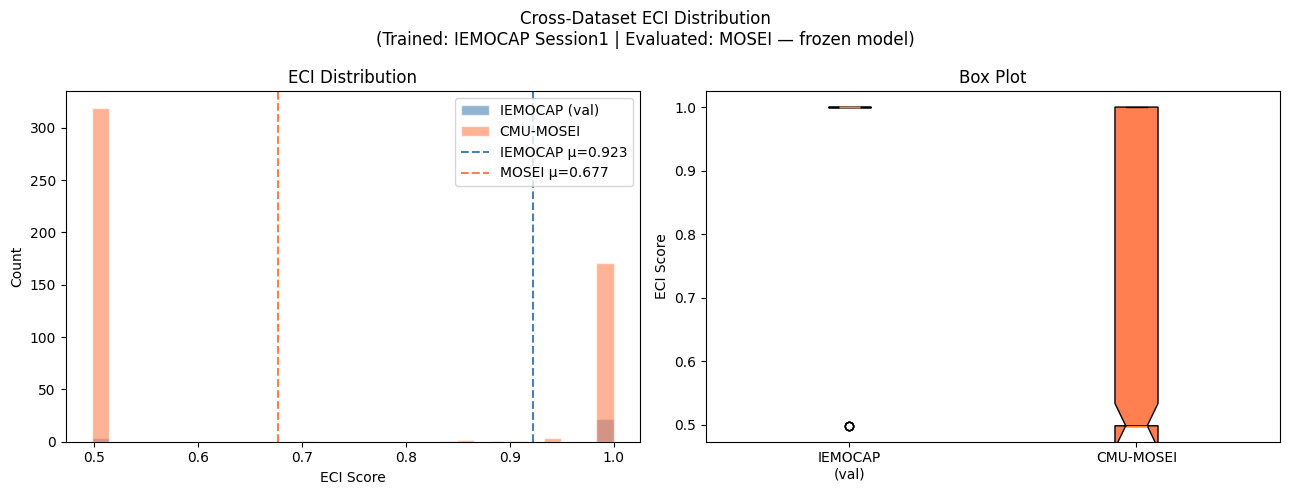

✓ Plot saved to Drive


In [36]:
import matplotlib.pyplot as plt
import numpy as np, csv
from pathlib import Path

RESULTS_DIR = Path('/content/drive/MyDrive/emotion_regulation/results')

def load_eci(path):
    with open(path) as f:
        return [float(row['eci']) for row in csv.DictReader(f)]

iemocap_eci = load_eci(RESULTS_DIR / 'eci_scores_iemocap.csv')
mosei_eci   = load_eci(RESULTS_DIR / 'eci_scores_mosei.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Cross-Dataset ECI Distribution\n'
             '(Trained: IEMOCAP Session1 | Evaluated: MOSEI — frozen model)', fontsize=12)

axes[0].hist(iemocap_eci, bins=30, alpha=0.6, color='steelblue', label='IEMOCAP (val)', edgecolor='white')
axes[0].hist(mosei_eci,   bins=30, alpha=0.6, color='coral',     label='CMU-MOSEI',     edgecolor='white')
axes[0].axvline(np.mean(iemocap_eci), color='steelblue', ls='--', lw=1.5, label=f'IEMOCAP μ={np.mean(iemocap_eci):.3f}')
axes[0].axvline(np.mean(mosei_eci),   color='coral',     ls='--', lw=1.5, label=f'MOSEI μ={np.mean(mosei_eci):.3f}')
axes[0].set_xlabel('ECI Score'); axes[0].set_ylabel('Count')
axes[0].set_title('ECI Distribution'); axes[0].legend()

bp = axes[1].boxplot([iemocap_eci, mosei_eci],
                     labels=['IEMOCAP\n(val)','CMU-MOSEI'],
                     patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
axes[1].set_ylabel('ECI Score'); axes[1].set_title('Box Plot')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eci_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Plot saved to Drive')

## 💾 STEP 16: Download Checkpoints + Results to Mac

In [37]:
!cp -r /content/drive/MyDrive/emotion_regulation/checkpoints /content/checkpoints_export
!cp -r /content/drive/MyDrive/emotion_regulation/results     /content/results_export
!cp /content/emotion_regulation/code/utils/config.py         /content/checkpoints_export/

!cd /content && zip -r checkpoints.zip checkpoints_export/
!cd /content && zip -r results.zip     results_export/

!echo 'Package sizes:'
!ls -lh /content/checkpoints.zip /content/results.zip

  adding: checkpoints_export/ (stored 0%)
  adding: checkpoints_export/config.py (deflated 48%)
  adding: checkpoints_export/incongruence_encoder_best.pth (deflated 8%)
  adding: checkpoints_export/temporal_model_best.pth (deflated 6%)
  adding: results_export/ (stored 0%)
  adding: results_export/cross_dataset_results.json (deflated 53%)
  adding: results_export/eci_scores_mosei.csv (deflated 78%)
  adding: results_export/eci_comparison.png (deflated 17%)
  adding: results_export/eci_scores_iemocap.csv (deflated 56%)
Package sizes:
-rw-r--r-- 1 root root 6.3M Mar 12 03:22 /content/checkpoints.zip
-rw-r--r-- 1 root root  70K Mar 12 03:22 /content/results.zip


In [38]:
from google.colab import files
files.download('/content/checkpoints.zip')
files.download('/content/results.zip')
print('\n✅ Downloads started!')
print('\ncheckpoints.zip  →  incongruence_encoder_best.pth + temporal_model_best.pth + config.py')
print('results.zip      →  ECI CSVs + JSON + distribution plot')
print('\nTransfer both to your M4 Mac, then ask for the inference code.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloads started!

checkpoints.zip  →  incongruence_encoder_best.pth + temporal_model_best.pth + config.py
results.zip      →  ECI CSVs + JSON + distribution plot

Transfer both to your M4 Mac, then ask for the inference code.


## ✅ Complete

| Stage | Data | Notes |
|-------|------|-------|
| Train (80%) | IEMOCAP Session1 | Only session with .avi video |
| Val (20%) | IEMOCAP Session1 | Held-out split |
| Eval | CMU-MOSEI 500 clips | Frozen model — cross-dataset |


